# Objetivo 2

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
from lightgbm import early_stopping, log_evaluation

In [2]:
LGB_PARAMS = dict(
    objective="binary",

    learning_rate=0.01,
    num_leaves=31,
    max_depth=6,

    feature_fraction=0.65,
    bagging_fraction=0.65,
    bagging_freq=1,

    n_estimators=150,

    verbose=-1,
    random_state=42,
    n_jobs=-1,
)

In [3]:
bolivia_train = pd.read_csv('../data/bolivia_train_cleaned.csv')
brasil_train = pd.read_csv('../data/brasil_train_cleaned.csv')
guate_train = pd.read_csv('../data/guatemala_train_cleaned.csv')
bolivia_test = pd.read_csv('../data/bolivia_test_cleaned.csv')
brasil_test = pd.read_csv('../data/brasil_test_cleaned.csv')
guate_test = pd.read_csv('../data/guatemala_test_cleaned.csv')

In [4]:
dfs = [bolivia_train, bolivia_test, brasil_train, brasil_test]
def print_desbalance(df):
    print(df['is_fraud'].value_counts())

for df in dfs:
    print_desbalance(df)

is_fraud
0    79645
1     4191
Name: count, dtype: int64
is_fraud
0    15439
1      728
Name: count, dtype: int64
is_fraud
0    81262
1     2680
Name: count, dtype: int64
is_fraud
0    15533
1      525
Name: count, dtype: int64


In [5]:
"""
Federated Fraud Detection - LightGBM con 3 Metodologías
=========================================================
Bolivia + Brasil → predicción sobre Guatemala (30% = 3 tercios × 10%)

Metodologías:
  Tercio 1 → Modelo 1: FedAvg simulado (promediar pesos de modelos por banco)
  Tercio 2 → Modelo 2: Federated con domain-agnostic features + SMOTE
  Tercio 3 → Modelo 3: Stacking federado (meta-modelo sobre predicciones de ambos bancos)

Desbalance: ~19:1 → se manejan con scale_pos_weight / SMOTE / threshold tuning
"""

bolivia_fe = pd.concat([bolivia_train, bolivia_test], ignore_index=True)
brasil_fe  = pd.concat([brasil_train,  brasil_test],  ignore_index=True)
guate_fe   = pd.concat([guate_train,   guate_test],   ignore_index=True)

print(f"Bolivia total: {len(bolivia_fe):,}  fraudes: {bolivia_fe['is_fraud'].sum():,}")
print(f"Brasil  total: {len(brasil_fe):,}  fraudes: {brasil_fe['is_fraud'].sum():,}")
print(f"Guatemala total (inferencia): {len(guate_fe):,}")

EXCLUDE_COLS = {'is_fraud', 'transaction_id'}
 
def get_feature_cols(df, exclude=EXCLUDE_COLS):
    return [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude]
 
COMMON_FEATURES = sorted(
    set(get_feature_cols(bolivia_fe)) &
    set(get_feature_cols(brasil_fe)) &
    set(get_feature_cols(guate_fe)))


n_guate = len(guate_fe)
t1 = n_guate // 3

guate_t1 = guate_fe.iloc[:t1].copy()            





Bolivia total: 100,003  fraudes: 4,919
Brasil  total: 100,000  fraudes: 3,205
Guatemala total (inferencia): 100,000


In [6]:
def get_spw(y):
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    return neg / pos

In [7]:
X_bra_inicial = brasil_fe[COMMON_FEATURES].fillna(0)
y_bra_inicial = brasil_fe["is_fraud"]


X_bol_inicial = bolivia_fe[COMMON_FEATURES].fillna(0)
y_bol_inicial = bolivia_fe["is_fraud"]

In [8]:
combined = pd.concat(
    [bolivia_fe, brasil_fe],
    ignore_index=True
)

In [9]:
X_global_inicial = combined[COMMON_FEATURES].fillna(0)
y_global_inicial = combined["is_fraud"]

In [10]:
X_bol, X_bol_val, y_bol, y_bol_val = train_test_split(
    X_bol_inicial,
    y_bol_inicial,
    test_size=0.20,
    stratify=y_bol_inicial,
    random_state=42
)

In [11]:
X_bra, X_bra_val, y_bra, y_bra_val = train_test_split(
    X_bra_inicial,
    y_bra_inicial,
    test_size=0.20,
    stratify=y_bra_inicial,
    random_state=42
)

In [12]:
X_global, X_global_val, y_global, y_global_val = train_test_split(
    X_global_inicial,
    y_global_inicial,
    test_size=0.20,
    stratify=y_global_inicial,
    random_state=42
)

In [13]:
spw_bol = get_spw(bolivia_fe.is_fraud)
spw_bra = get_spw(brasil_fe.is_fraud)

combined_tmp = pd.concat(
    [bolivia_fe, brasil_fe]
)

spw_global = get_spw(
    combined_tmp.is_fraud
)

print(spw_bol)
print(spw_bra)
print(spw_global)

19.329945110794878
30.201248049921997
23.61878385032004


In [14]:

model_bol = lgb.LGBMClassifier(
   **LGB_PARAMS,
   scale_pos_weight=spw_bol
)

model_bol.fit(X_bol, y_bol, eval_set=[(X_bol_val, y_bol_val)], 
    callbacks=[early_stopping(stopping_rounds= 100 ), log_evaluation(period= 100 )] )

Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.191906
Early stopping, best iteration is:
[28]	valid_0's binary_logloss: 0.165884


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:

m_bra = lgb.LGBMClassifier(
    **LGB_PARAMS,
    scale_pos_weight=spw_bra
)

m_bra.fit(X_bra, y_bra, eval_set=[(X_bra_val, y_bra_val)], 
    callbacks=[early_stopping(stopping_rounds= 100 ), log_evaluation(period= 100 )] )

Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.199523
Early stopping, best iteration is:
[8]	valid_0's binary_logloss: 0.127571


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [16]:
X_g1 = guate_t1[COMMON_FEATURES].fillna(0)

prob_bol = model_bol.predict_proba(X_g1)[:,1]
prob_bra = m_bra.predict_proba(X_g1)[:,1]

In [17]:
w_bol = len(bolivia_fe) / (len(bolivia_fe)+len(brasil_fe))
w_bra = len(brasil_fe) / (len(bolivia_fe)+len(brasil_fe))

In [18]:
prob_fedavg = (
    w_bol * prob_bol
    + w_bra * prob_bra
)

In [19]:
fedavg_results = pd.DataFrame({
    "prob_fraud": prob_fedavg,
    "is_fraud": prob_fedavg >= 0.50
})

fedavg_results.to_excel(
    "fedavg_tercio1.xlsx",
    index=False
)

In [20]:
# Validación federada
X_fed_val = pd.concat(
    [X_bol_val, X_bra_val],
    ignore_index=True
)

y_fed_val = pd.concat(
    [y_bol_val, y_bra_val],
    ignore_index=True
)

In [21]:
# Predicción Bolivia sobre validación federada
prob_bol_val = model_bol.predict_proba(
    X_fed_val
)[:, 1]

# Predicción Brasil sobre validación federada
prob_bra_val = m_bra.predict_proba(
    X_fed_val
)[:, 1]

# Ensemble federado
prob_fedavg_val = (
    w_bol * prob_bol_val +
    w_bra * prob_bra_val
)

pred_fedavg_val = (
    prob_fedavg_val >= 0.50
).astype(int)

In [22]:

print("========== FEDAVG ==========")

print(
    "ROC-AUC:",
    roc_auc_score(
        y_fed_val,
        prob_fedavg_val
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_fed_val,
        prob_fedavg_val
    )
)

print(
    "Recall:",
    recall_score(
        y_fed_val,
        pred_fedavg_val
    )
)

print(
    "Precision:",
    precision_score(
        y_fed_val,
        pred_fedavg_val
    )
)

print(
    "F1:",
    f1_score(
        y_fed_val,
        pred_fedavg_val
    )
)

========== FEDAVG ==========
ROC-AUC: 0.8762363336059397
PR-AUC: 0.7029473009383446
Recall: 0.0
Precision: 0.0
F1: 0.0


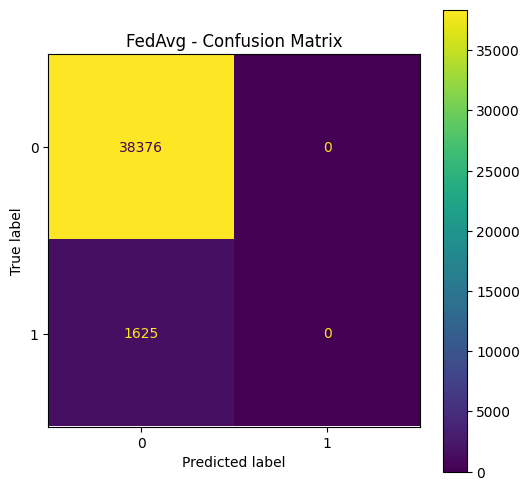

In [23]:
cm = confusion_matrix(
    y_fed_val,
    pred_fedavg_val
)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=ax)

plt.title("FedAvg - Confusion Matrix")

plt.show()

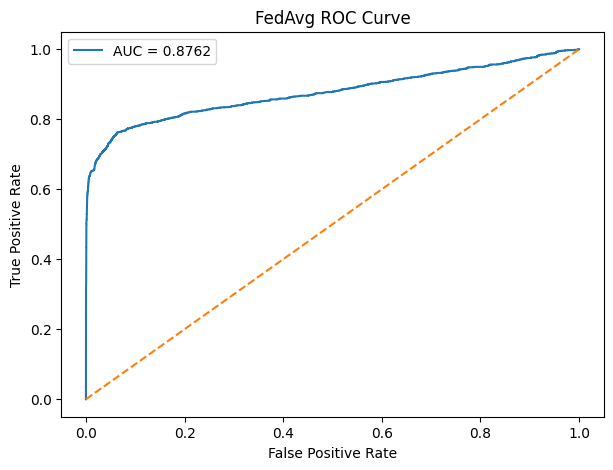

In [24]:
fpr, tpr, _ = roc_curve(
    y_fed_val,
    prob_fedavg_val
)

auc = roc_auc_score(
    y_fed_val,
    prob_fedavg_val
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FedAvg ROC Curve")

plt.legend()

plt.show()

## Modelo 2

In [25]:
m_global = lgb.LGBMClassifier(
    **LGB_PARAMS,
    scale_pos_weight=spw_global
)

m_global.fit(
    X_global,
    y_global,
    eval_set=[(X_global_val, y_global_val)], 
    callbacks=[early_stopping(stopping_rounds= 100 ), log_evaluation(period= 100 )] )

Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.205999
Early stopping, best iteration is:
[12]	valid_0's binary_logloss: 0.150484


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [26]:
X_g2 = guate_t1[COMMON_FEATURES].fillna(0)

prob_global = m_global.predict_proba(X_g2)[:,1]

In [27]:
global_results = pd.DataFrame({
    "prob_fraud": prob_global,
    "is_fraud": prob_global >= 0.50
})

global_results.to_excel(
    "global_pooling_tercio2.xlsx",
    index=False
)

In [28]:
prob_global_val = m_global.predict_proba(
    X_global_val
)[:,1]

pred_global_val = (
    prob_global_val >= 0.50
).astype(int)

In [29]:


print("========== GLOBAL POOLING ==========")

print(
    f"ROC-AUC   : {roc_auc_score(y_global_val, prob_global_val):.4f}"
)

print(
    f"PR-AUC    : {average_precision_score(y_global_val, prob_global_val):.4f}"
)

print(
    f"Recall    : {recall_score(y_global_val, pred_global_val):.4f}"
)

print(
    f"Precision : {precision_score(y_global_val, pred_global_val):.4f}"
)

print(
    f"F1        : {f1_score(y_global_val, pred_global_val):.4f}"
)

========== GLOBAL POOLING ==========
ROC-AUC   : 0.8881
PR-AUC    : 0.7502
Recall    : 0.0000
Precision : 0.0000
F1        : 0.0000


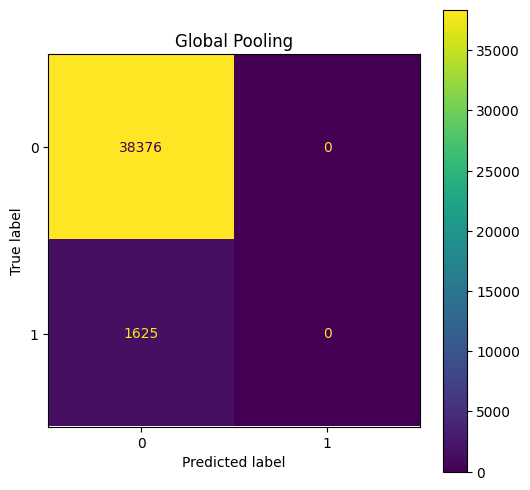

In [30]:
cm = confusion_matrix(
    y_global_val,
    pred_global_val
)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=ax)

plt.title("Global Pooling")
plt.show()

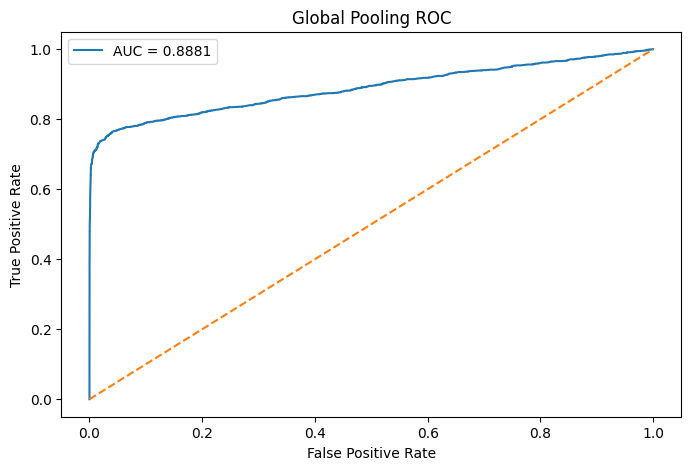

In [31]:

fpr, tpr, _ = roc_curve(
    y_global_val,
    prob_global_val
)

auc = roc_auc_score(
    y_global_val,
    prob_global_val
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Global Pooling ROC")

plt.legend()

plt.show()

## Modelo 3

In [32]:
model_robust = lgb.LGBMClassifier(
    **LGB_PARAMS, 
    scale_pos_weight=spw_global
)

In [33]:
model_robust.fit(
    X_global,
    y_global,
    eval_set=[(X_global_val, y_global_val)], 
    callbacks=[early_stopping(stopping_rounds= 100 ), log_evaluation(period= 100 )] )

Training until validation scores don't improve for 100 rounds
[100]	valid_0's binary_logloss: 0.205999
Early stopping, best iteration is:
[12]	valid_0's binary_logloss: 0.150484


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,6
,learning_rate,0.01
,n_estimators,150
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [34]:
X_g3 = guate_t1[COMMON_FEATURES].fillna(0)

prob_robust = model_robust.predict_proba(
    X_g3
)[:,1]

In [35]:
pd.DataFrame({
    "prob_fraud": prob_robust,
    "is_fraud": prob_robust >= 0.50
}).to_excel(
    "regularized_pooling_tercio3.xlsx",
    index=False
)

In [36]:
prob_global_val_m3 = model_robust.predict_proba(
    X_global_val
)[:,1]

pred_global_val_m3 = (
    prob_global_val_m3 >= 0.50
).astype(int)

In [37]:


print("========== GLOBAL POOLING ROBUSTO ==========")

print(
    f"ROC-AUC   : {roc_auc_score(y_global_val, prob_global_val_m3):.4f}"
)

print(
    f"PR-AUC    : {average_precision_score(y_global_val, prob_global_val_m3):.4f}"
)

print(
    f"Recall    : {recall_score(y_global_val, pred_global_val_m3):.4f}"
)

print(
    f"Precision : {precision_score(y_global_val, pred_global_val_m3):.4f}"
)

print(
    f"F1        : {f1_score(y_global_val, pred_global_val_m3):.4f}"
)

========== GLOBAL POOLING ROBUSTO ==========
ROC-AUC   : 0.8881
PR-AUC    : 0.7502
Recall    : 0.0000
Precision : 0.0000
F1        : 0.0000


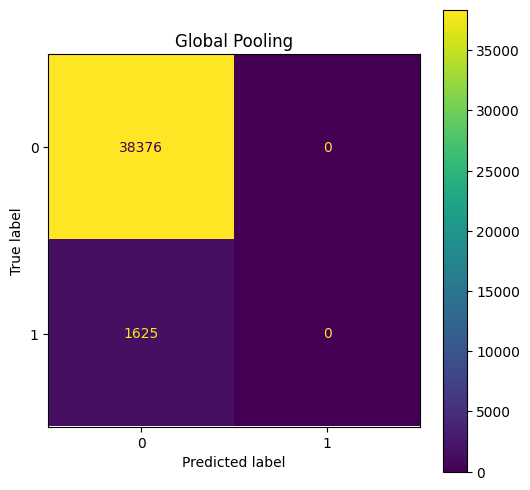

In [38]:
cm = confusion_matrix(
    y_global_val,
    pred_global_val_m3
)

fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(ax=ax)

plt.title("Global Pooling")
plt.show()

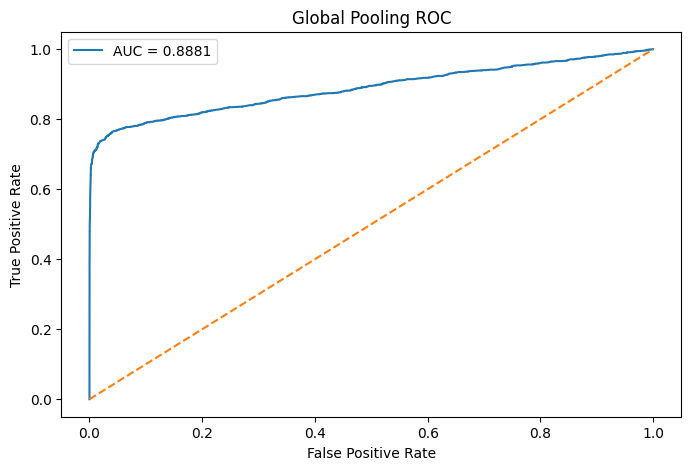

In [39]:


fpr, tpr, _ = roc_curve(
    y_global_val,
    prob_global_val_m3
)

auc = roc_auc_score(
    y_global_val,
    prob_global_val_m3
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Global Pooling ROC")

plt.legend()

plt.show()

In [ ]:
import lightgbm as lgb
import optuna
import numpy as np

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

def optimize_fraud_model(
    X_train,
    y_train,
    X_val,
    y_val,
    scale_pos_weight,
    min_precision=0.10,
    n_trials=50
):

    def objective(trial):

        params = {
            "objective": "binary",
            "metric": "auc",

            "learning_rate": trial.suggest_float(
                "learning_rate",
                0.005,
                0.05,
                log=True
            ),

            "num_leaves": trial.suggest_int(
                "num_leaves",
                15,
                127
            ),

            "max_depth": trial.suggest_int(
                "max_depth",
                3,
                10
            ),

            "min_child_samples": trial.suggest_int(
                "min_child_samples",
                20,
                300
            ),

            "feature_fraction": trial.suggest_float(
                "feature_fraction",
                0.5,
                1.0
            ),

            "bagging_fraction": trial.suggest_float(
                "bagging_fraction",
                0.5,
                1.0
            ),

            "bagging_freq": trial.suggest_int(
                "bagging_freq",
                1,
                10
            ),

            "reg_alpha": trial.suggest_float(
                "reg_alpha",
                0,
                10
            ),

            "reg_lambda": trial.suggest_float(
                "reg_lambda",
                0,
                10
            ),

            "scale_pos_weight": scale_pos_weight,

            "n_estimators": 5000,

            "verbose": -1,

            "random_state": 42,

            "n_jobs": -1
        }

        model = lgb.LGBMClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=100,
                    verbose=False
                )
            ]
        )

        prob = model.predict_proba(
            X_val
        )[:, 1]

        threshold = trial.suggest_float(
            "threshold",
            0.01,
            0.50
        )

        pred = (
            prob >= threshold
        ).astype(int)

        precision = precision_score(
            y_val,
            pred,
            zero_division=0
        )

        recall = recall_score(
            y_val,
            pred
        )

        if precision < min_precision:
            return 0

        return recall

    study = optuna.create_study(
        direction="maximize"
    )

    study.optimize(
        objective,
        n_trials=n_trials,
        show_progress_bar=True
    )

    print("\n===== BEST TRIAL =====")
    print("Recall:", study.best_value)

    print("\nBest params:")
    for k, v in study.best_params.items():
        print(f"{k}: {v}")

    return study